In [20]:
#install.packages("remotes")
#remotes::install_github("GotelliLab/EcoSimR")

In [21]:
library(EcoSimR)
library(cooccur)
library(ggplot2)

# Demo on built in dataset

                         Seymour Baltra Isabella Fernandina Santiago
Geospiza magnirostris          0      0        1          1        1
Geospiza fortis                1      1        1          1        1
Geospiza fuliginosa            1      1        1          1        1
Geospiza difficilis            0      0        1          1        1
Geospiza scandens              1      1        1          0        1
Geospiza conirostris           0      0        0          0        0
Camarhynchus psittacula        0      0        1          1        1
Camarhynchus pauper            0      0        0          0        0
Camarhynchus parvulus          0      0        1          1        1
Platyspiza crassirostris       0      0        1          1        1


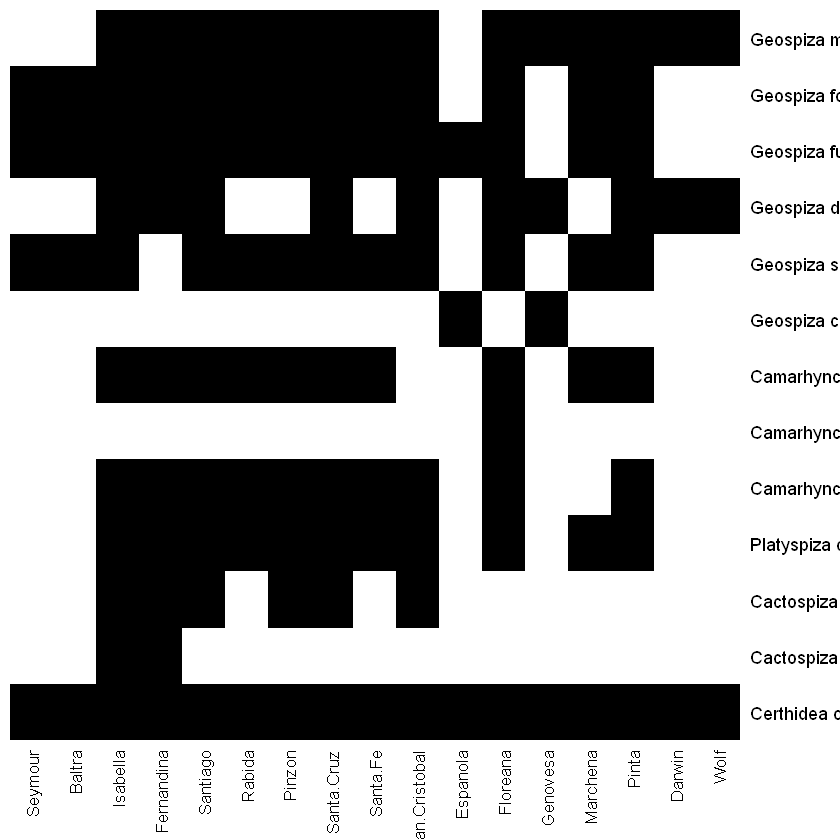

In [22]:
data(finches)
df <- finches

print(df[1:10, 1:5])

heatmap(as.matrix(df)[nrow(df):1, ], col = c("white", "black"), scale = "none",
        Rowv = NA, Colv = NA)

In [23]:
cat("Species:", nrow(df), "\n")
cat("Sites:", ncol(df), "\n")
cat("Total presences:", sum(df), "\n")
cat("Fill percent:", round(sum(df)/(nrow(df)*ncol(df)),2), "\n")
sort(round(rowSums(df)/ncol(df),3), decreasing=TRUE)    # occurrences per species
sort(round(colSums(df)/nrow(df),3), decreasing=TRUE)    # richness per site
c_score(as.matrix(df))

Species: 13 
Sites: 17 
Total presences: 122 
Fill percent: 0.55 


Certhidea olivacea    Geospiza magnirostris      Geospiza fuliginosa 
                   1.000                    0.824                    0.824 
         Geospiza fortis        Geospiza scandens Platyspiza crassirostris 
                   0.765                    0.706                    0.647 
     Geospiza difficilis  Camarhynchus psittacula    Camarhynchus parvulus 
                   0.588                    0.588                    0.588 
      Cactospiza pallida     Geospiza conirostris    Cactospiza heliobates 
                   0.353                    0.118                    0.118 
     Camarhynchus pauper 
                   0.059

Isabella    Fernandina      Santiago    Santa.Cruz      Floreana 
        0.846         0.769         0.769         0.769         0.769 
       Pinzon San.Cristobal         Pinta        Rabida      Santa.Fe 
        0.692         0.692         0.692         0.615         0.615 
     Marchena       Seymour        Baltra      Genovesa      Espanola 
        0.538         0.308         0.308         0.308         0.231 
       Darwin          Wolf 
        0.231         0.231

[1] 4.269231

Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
Time Stamp:  Thu May  7 21:05:39 2026 
Reproducible:  
Number of Replications:  
Elapsed Time:  3.4 secs 
Metric:  c_score 
Algorithm:  sim9 
Observed Index:  4.2692 
Mean Of Simulated Index:  3.1191 
Variance Of Simulated Index:  0.027016 
Lower 95% (1-tail):  2.9103 
Upper 95% (1-tail):  3.4103 
Lower 95% (2-tail):  2.8462 
Upper 95% (2-tail):  3.5256 
Lower-tail P >  0.9998 
Upper-tail P <  2e-04 
Observed metric > 5000 simulated metrics 
Observed metric < 0 simulated metrics 
Observed metric = 0 simulated metrics 
Standardized Effect Size (SES):  6.9972 


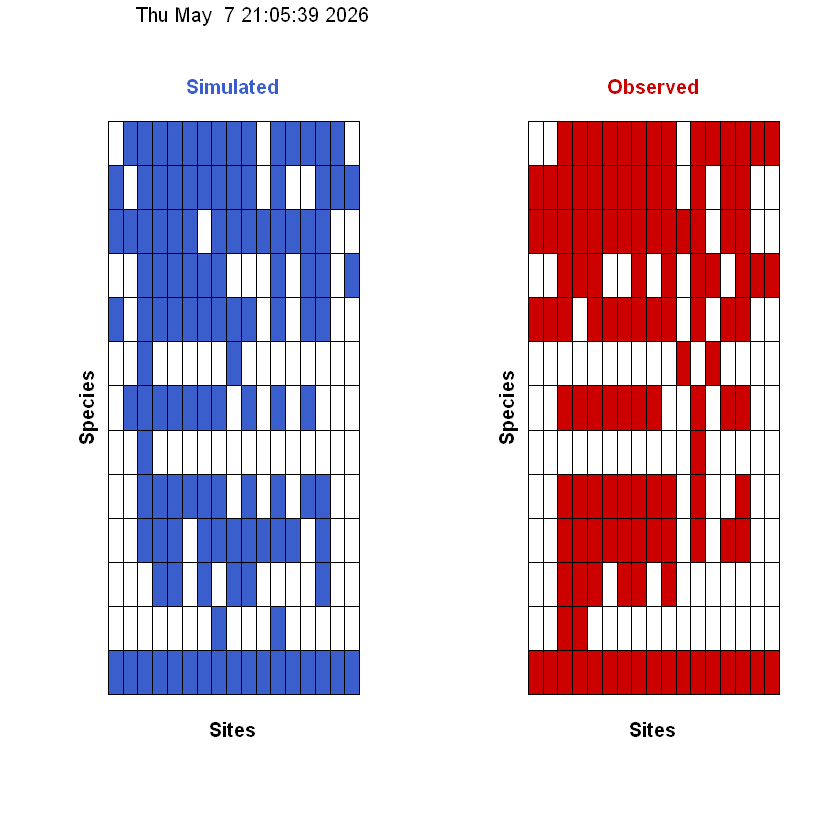

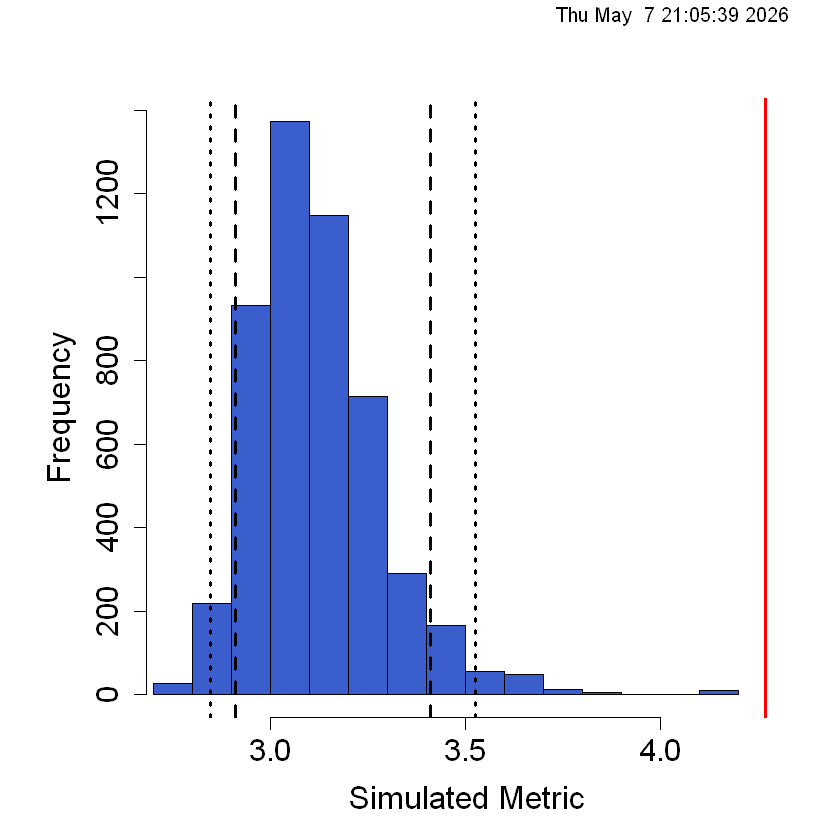

In [24]:
############################
# cooccurence null model
############################
df_cooc <- cbind(ID = rownames(df), df)
rownames(df_cooc) <- NULL
nullMod <- cooc_null_model(df_cooc, algo = "sim9",  burn_in = 50000, nReps = 5000)
summary(nullMod)
plot(nullMod, type = "cooc")
plot(nullMod, type = "hist")

## Results: Sanderson (2000) Finches — Demo Dataset

**Significant checkerboard structure detected** — species co-occur less than expected by chance.

| Metric | Value |
|---|---|
| Observed C-score | 4.XX |
| Mean simulated | 3.130 |
| SES | 6.XX |
| P-value (upper-tail) | < 0.0001 |

- Observed C-score exceeded all 10,000 null model replicates (sim9)
- 13 species × 17 islands

**Interpretation:** Finch species are significantly segregated across the 17 sites, consistent with competitive exclusion or island-level habitat partitioning. 

In [25]:
#cooc_data <- "pres_abs_stratum.csv"
cooc_data <- "pres_abs_lcode.csv"
df <- read.csv(cooc_data, header=TRUE)
df_richness <- df[c(-1,-2),-1]
df_richness[] <- lapply(df_richness, function(x) as.numeric(as.character(x)))
t(t(sort(colSums(df_richness), decreasing=TRUE)[1:10]))
t(t(sort(colSums(df_richness), decreasing=FALSE)[1:10]))

I157.8V_2003_LG,28
I80.0_1998_LG,26
I157.8V_2005_LG,26
I157.8V_2007_LG,26
D32.RS_2013_LG,26
I157.8Vb_2015_LG,26
I157.8V_1995_LG,25
I157.8V_2004_LG,25
F167A.RS_2013_LG,25
F372A.RS_2017_LG,25


D23.RS_2016_26,1
D18.RS_1993_26,2
D10.RS_2002_26,2
B29A.RS_2006_26,2
F42A.RS_2014_26,2
D24.RS_2018_26,2
D8.RS_1999_LG,2
D2.RS_2000_LG,2
D30.RS_2008_LG,2
I113.0Ta_2008_LG,2


# Ecosim Routines

In [26]:
run_ecosim <- function(pool="both", breakpoint="<=2007", nReps=10000/2, burn_in=25000/2) {
    
    ############################
    # load data
    ############################
    df <- read.csv(cooc_data, header=TRUE)
    if (pool != "both") {
        ind <- which(df[1,] == pool)
        df <- df[,c(1,ind)]
    }
    df <- df[-1,] # drop pool row

    # year breakpoint
    if (breakpoint == "<=2007") {
        ind <- which(df[1,2:ncol(df)] <= 2007)+1 # before breakpoint
    } else {
        ind <- which(df[1,2:ncol(df)] > 2007)+1 # after breakpoint
    }
    df <- df[,c(1,ind)]
    df <- df[2:nrow(df), ]
    rownames(df) <- df[,1]  
    df <- df[, -1]

    df[] <- lapply(df, function(x) as.numeric(as.character(x)))

    df <- df[rowSums(df) > 0, ] # remove species with no occurrences
    print(dim(df))
    print(df[1:5, 1:5])

    ############################
    # viz cooccurence matrix
    ############################

    heatmap(as.matrix(df)[nrow(df):1, ], col = c("white", "black"), scale = "none",
            Rowv = NA, Colv = NA, cexRow = 0.5, cexCol = 0.6)

    ############################
    # summary stats
    ############################
    cat("Species:", nrow(df), "\n")
    cat("Sites:", ncol(df), "\n")
    cat("Total presences:", sum(df), "\n")
    cat("Fill percent:", round(sum(df)/(nrow(df)*ncol(df)),2), "\n")
    sort(round(rowSums(df)/ncol(df),3), decreasing=TRUE)[1:5]    # occurrences per species
    sort(round(colSums(df)/nrow(df),3), decreasing=TRUE)[1:5]    # richness per site
    c_score(as.matrix(df))

    ############################
    # cooccurence null model
    ############################
    df_cooc <- cbind(ID = rownames(df), df)
    rownames(df_cooc) <- NULL
    nullMod <- cooc_null_model(df_cooc, algo = "sim9", nReps = nReps,  burn_in = burn_in)
    summary(nullMod)
    #plot(nullMod, type = "cooc")
    plot(nullMod, type = "hist")
}

In [27]:
run_yearly_ecosim <- function(pool="both", years, nReps=10000, burn_in=25000) {
    
    ############################
    # load data
    ############################
    df <- read.csv(cooc_data, header=TRUE)
    if (pool != "both") {
        ind <- which(df[1,] == pool)
        df <- df[,c(1,ind)]
    }
    df <- df[-1,] # drop pool row

    # year breakpoint
    ind <- which(is.element(df[1,2:ncol(df)],years))+1 # before breakpoint
    
    df <- df[,c(1,ind)]
    df <- df[2:nrow(df), ]
    rownames(df) <- df[,1]  
    df <- df[, -1]

    df[] <- lapply(df, function(x) as.numeric(as.character(x)))

    df <- df[rowSums(df) > 0, ] # remove species with no occurrences
    
    ############################
    # cooccurence null model
    ############################
    df_cooc <- cbind(ID = rownames(df), df)
    rownames(df_cooc) <- NULL
    nullMod <- cooc_null_model(df_cooc, algo = "sim9", nReps = nReps,  burn_in = burn_in)
    return(nullMod)
}

In [28]:

run_ecosim_loop <- function(pool="both", year_chunks, nReps=10000/2, burn_in=25000/2) {
    results_df <- data.frame()

    for (ys in year_chunks) {
    print(paste("Running years:", paste(min(ys), max(ys), sep = "-")))
    null_mod <- run_yearly_ecosim(pool=pool, years = ys, nReps=nReps, burn_in=burn_in)

    ses_val <- (null_mod$Obs - mean(null_mod$Sim)) / sd(null_mod$Sim)
    obs_val <- null_mod$Obs
    exp_val <- mean(null_mod$Sim)
    sd_val  <- sd(null_mod$Sim)

    results_df <- rbind(
        results_df,
        data.frame(
        year = if (length(ys) == 1) {
            as.character(ys)
            } else {
            paste(min(ys), max(ys), sep = "-")
            },
        SES = ses_val,
        obs = obs_val,
        exp = exp_val,
        sd  = sd_val
        )
    )
    }

    # Ensure chronological order for chunk labels
    results_df$year <- factor(results_df$year, levels = results_df$year, ordered = TRUE)

    # SES plot
    p <- ggplot(results_df, aes(year, SES, group = 1)) +
    geom_hline(yintercept = 0, linetype = "dashed", linewidth = 1.2) +
    geom_hline(yintercept = c(-2, 2),
                linetype = "dotted",
                color = "red", linewidth = 1.2) +
    geom_line(linewidth = 1.2, color = "blue") +
    geom_point(size = 3, color = "blue") +
    theme_bw(base_size = 14) +
    theme(
        axis.text.x = element_text(angle = 90, vjust = 0.5)
    ) +
    labs(
        title = "Fish community co-occurrence structure (SES)",
        x = "Year",
        y = "SES"
    )

    print(p)


    # Observed vs expected plot
    #q <- ggplot(results_df, aes(year, group = 1)) +
    #geom_ribbon(aes(ymin = exp - sd,
    #                ymax = exp + sd),
    #            fill = "gray70",
    #            alpha = 0.4) +
    #geom_line(aes(y = exp),
    #            linetype = "dashed",
    #            linewidth = 1,
    #            color = "red") +
    #geom_line(aes(y = obs),
    #            linewidth = 1.2,
    #            color = "black") +
    #geom_point(aes(y = obs),
    #            size = 2.5,
    #            color = "black") +
    #theme_bw(base_size = 14) +
    #theme(
    #    axis.text.x = element_text(angle = 90, vjust = 0.5)
    #) +
    #labs(
    #    title = "Observed vs Null C-score dynamics",
    #    x = "Year",
    #    y = "C-score"
    #)

    #print(q)

    #print(results_df)
}

# Combined pools

## <= 2007

[1]  60 925
     D1.RS_1993_26 D10.RS_1993_26 D11.RS_1993_26 D12.RS_1993_26 D13.RS_1993_26
BHCP             0              0              0              0              0
BHMW             1              1              0              0              0
BKBF             1              1              0              0              0
BKCP             0              0              0              0              0
BKSS             0              1              0              0              0
Species: 60 
Sites: 925 
Total presences: 10996 
Fill percent: 0.2 
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
Time Stamp:  Thu May  7 21:06:32 2026 
Reproducible:  
Number of Replications:  
Elapsed Time:  51 secs 
Metric:  c_score 
Algorithm:  sim9 
Observed Index:  7251.3 
Mean Of Simulated Index:  7146.5 
Variance Of Simulated Index:  197.77 
Lower 95% (1-ta

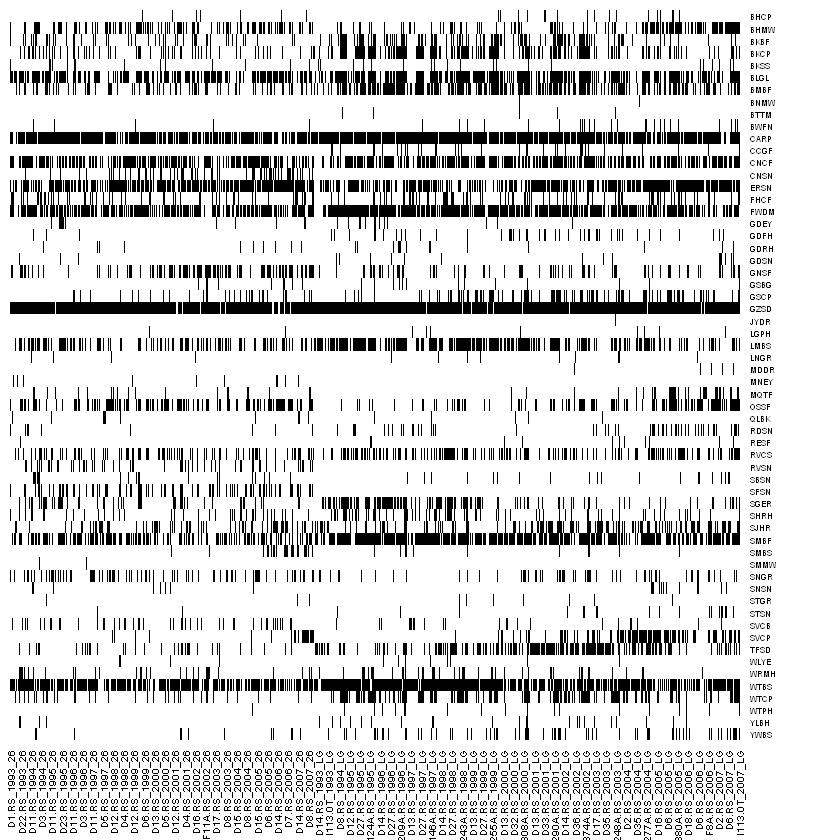

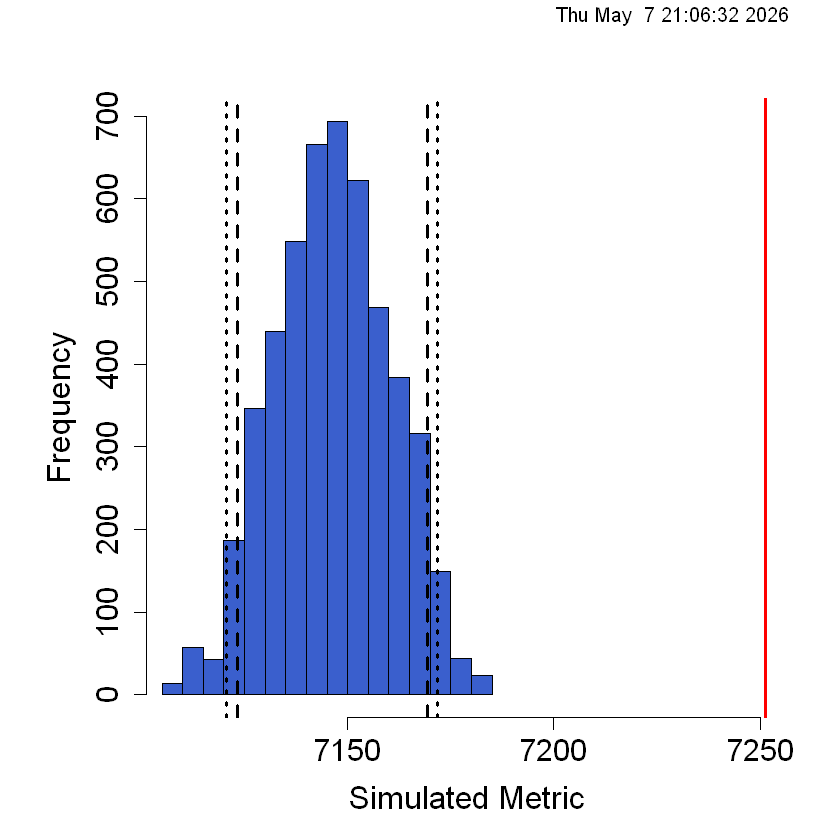

In [29]:
run_ecosim(pool="both", breakpoint="<=2007")

## > 2007

[1]   61 1117
     B27A.RS_2008_26 B3A.RS_2008_26 C48A.RS_2008_26 D1.RS_2008_26
BHCP               0              0               0             0
BHMW               0              0               0             0
BKBF               0              1               1             0
BKCP               0              0               0             1
BKSS               0              0               0             0
     D11.RS_2008_26
BHCP              0
BHMW              0
BKBF              0
BKCP              0
BKSS              1
Species: 61 
Sites: 1117 
Total presences: 13470 
Fill percent: 0.2 
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
Time Stamp:  Thu May  7 21:07:24 2026 
Reproducible:  
Number of Replications:  
Elapsed Time:  51 secs 
Metric:  c_score 
Algorithm:  sim9 
Observed Index:  13092 
Mean Of Simulated Index:  12995 
Variance O

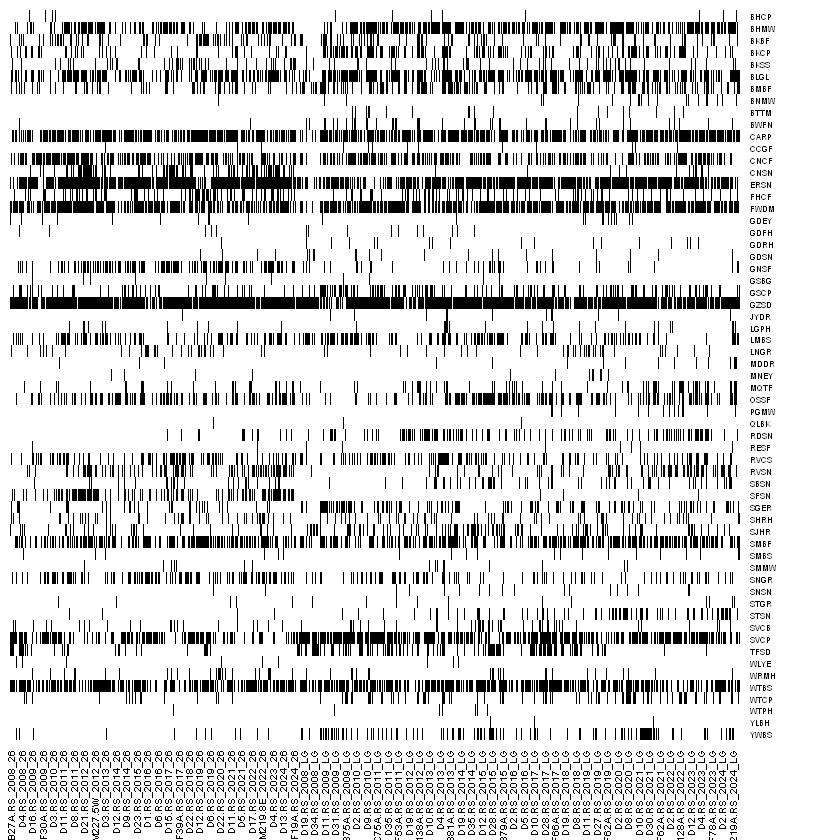

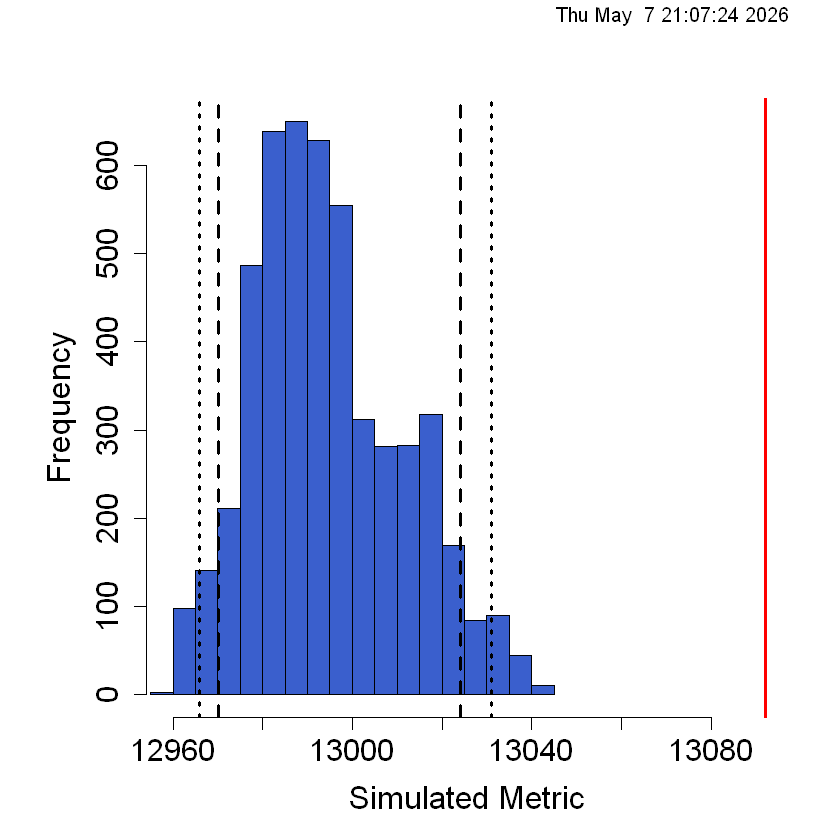

In [30]:
run_ecosim(pool="both", breakpoint=">2007")

## SES year chunks

[1] "Running years: 1993-1999"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 2000-2007"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 2008-2014"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 2015-2024"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 1993-1993"
Burn-in Progress 
  |====================================================

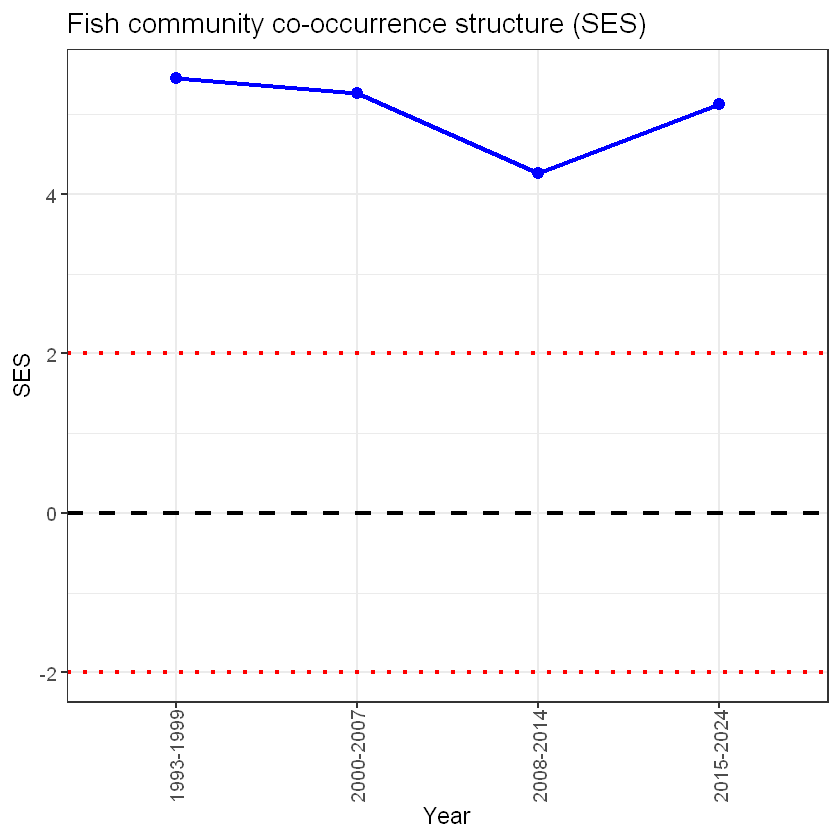

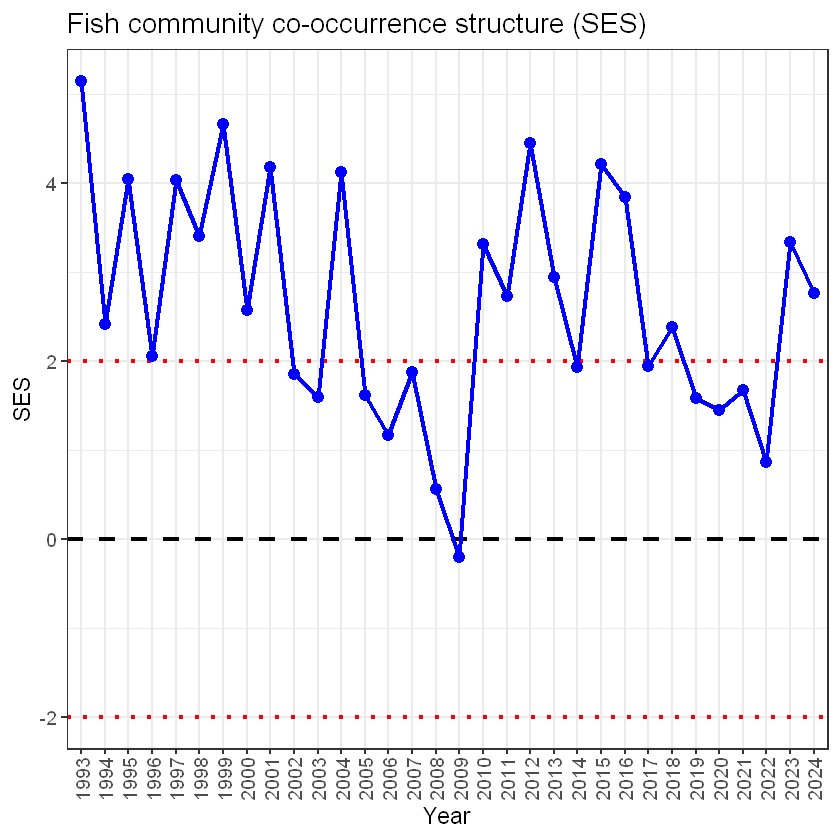

In [31]:
year_chunks <- list(1993:1999, 2000:2007, 2008:2014, 2015:2024)
run_ecosim_loop(pool="both", year_chunks) 

year_chunks <- c(1993:2024)
run_ecosim_loop(pool="both", year_chunks)


# Pool 26

## <= 2007

[1]  56 385
     D1.RS_1993_26 D10.RS_1993_26 D11.RS_1993_26 D12.RS_1993_26 D13.RS_1993_26
BHCP             0              0              0              0              0
BHMW             1              1              0              0              0
BKBF             1              1              0              0              0
BKCP             0              0              0              0              0
BKSS             0              1              0              0              0
Species: 56 
Sites: 385 
Total presences: 4157 
Fill percent: 0.19 
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
Time Stamp:  Thu May  7 21:11:53 2026 
Reproducible:  
Number of Replications:  
Elapsed Time:  16 secs 
Metric:  c_score 
Algorithm:  sim9 
Observed Index:  1285.1 
Mean Of Simulated Index:  1271.3 
Variance Of Simulated Index:  10.427 
Lower 95% (1-ta

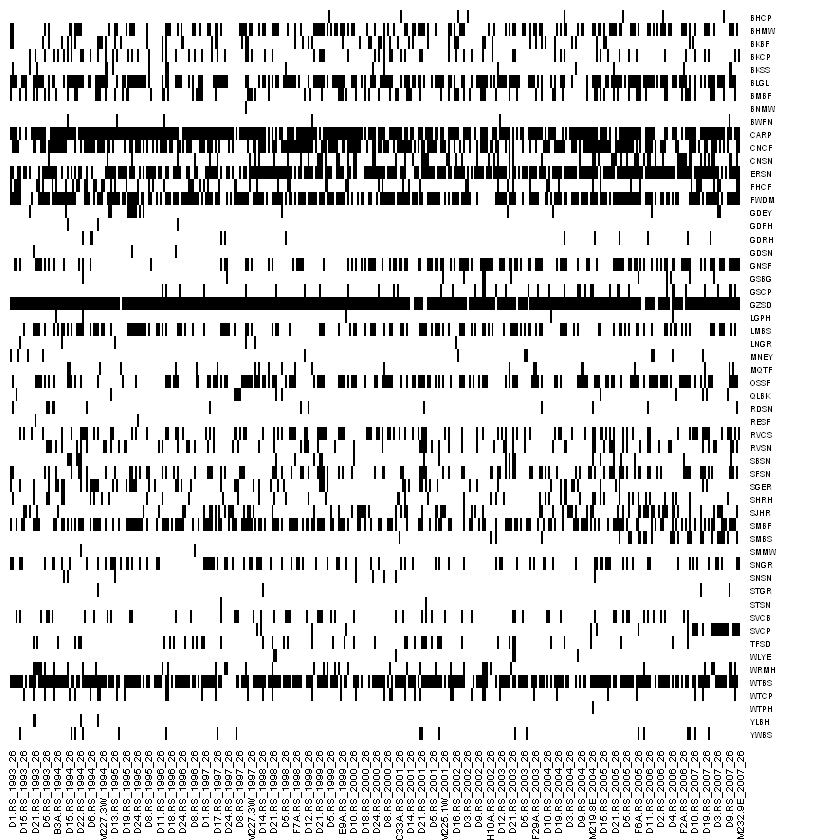

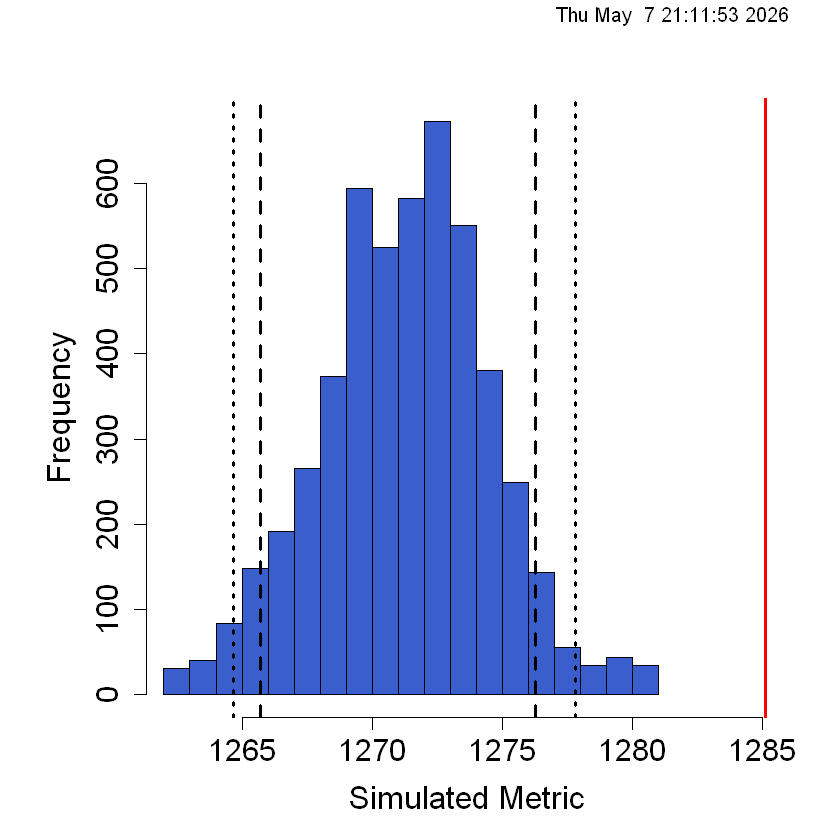

In [32]:
run_ecosim(pool=26, breakpoint="<=2007")

## > 2007

[1]  58 438
     B27A.RS_2008_26 B3A.RS_2008_26 C48A.RS_2008_26 D1.RS_2008_26
BHCP               0              0               0             0
BHMW               0              0               0             0
BKBF               0              1               1             0
BKCP               0              0               0             1
BKSS               0              0               0             0
     D11.RS_2008_26
BHCP              0
BHMW              0
BKBF              0
BKCP              0
BKSS              1
Species: 58 
Sites: 438 
Total presences: 5146 
Fill percent: 0.2 
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
Time Stamp:  Thu May  7 21:12:11 2026 
Reproducible:  
Number of Replications:  
Elapsed Time:  18 secs 
Metric:  c_score 
Algorithm:  sim9 
Observed Index:  1891.6 
Mean Of Simulated Index:  1872.4 
Variance Of 

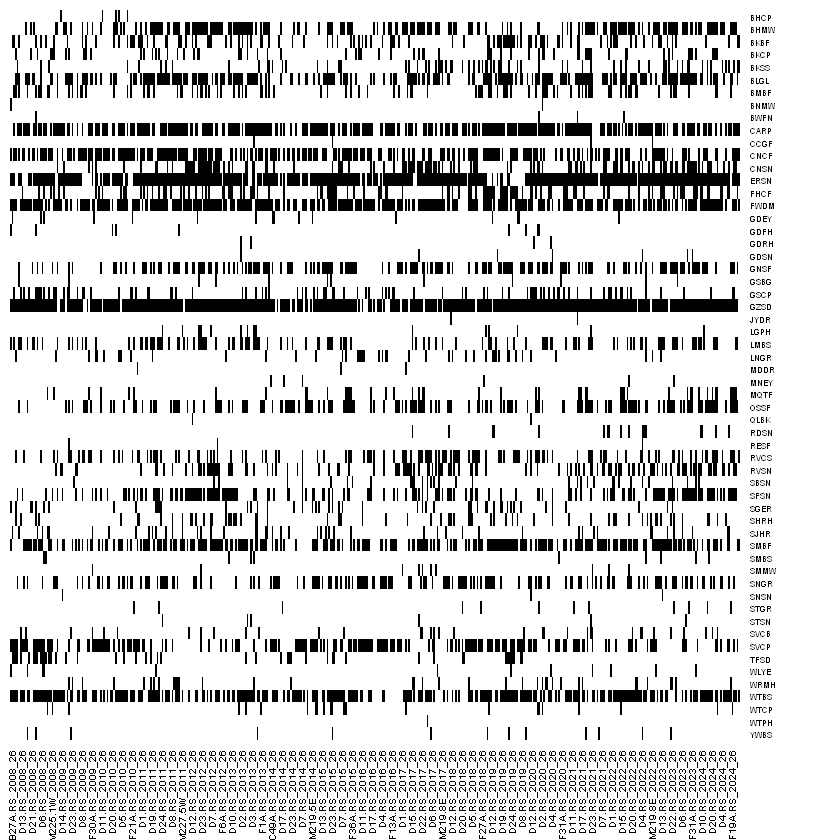

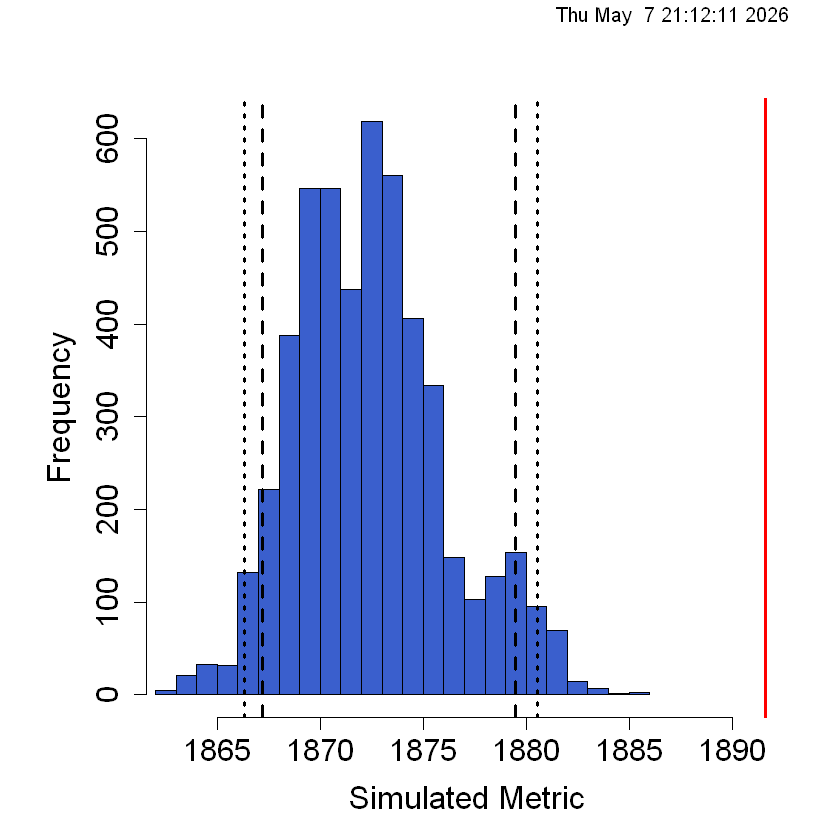

In [33]:
run_ecosim(pool=26, breakpoint=">2007")

## SES year chunks

[1] "Running years: 1993-1999"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 2000-2007"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 2008-2014"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 2015-2024"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 1993-1993"
Burn-in Progress 
  |====================================================

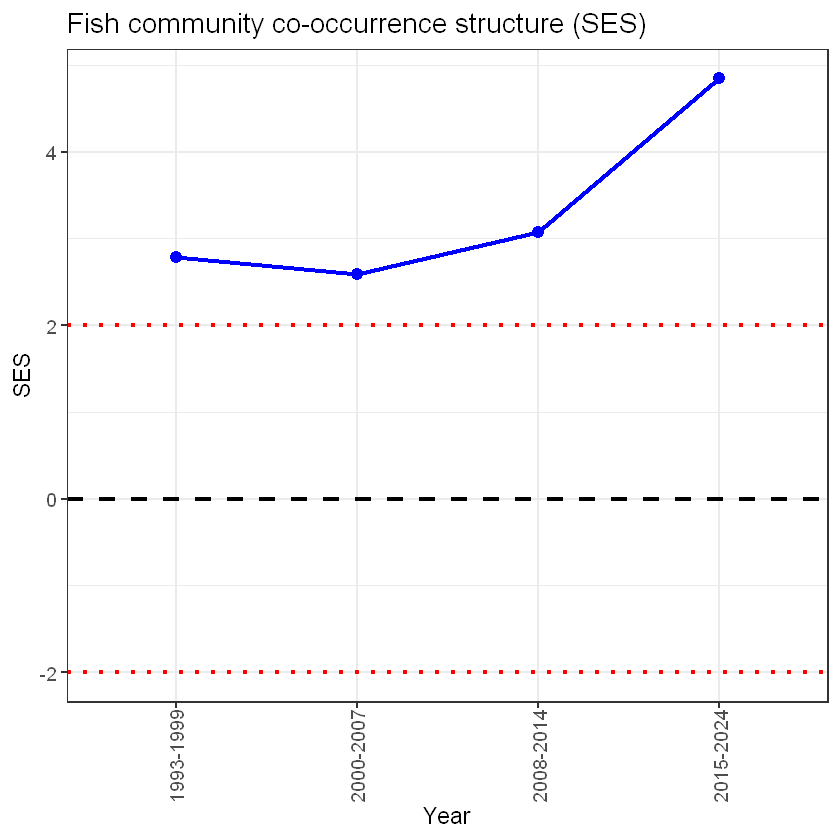

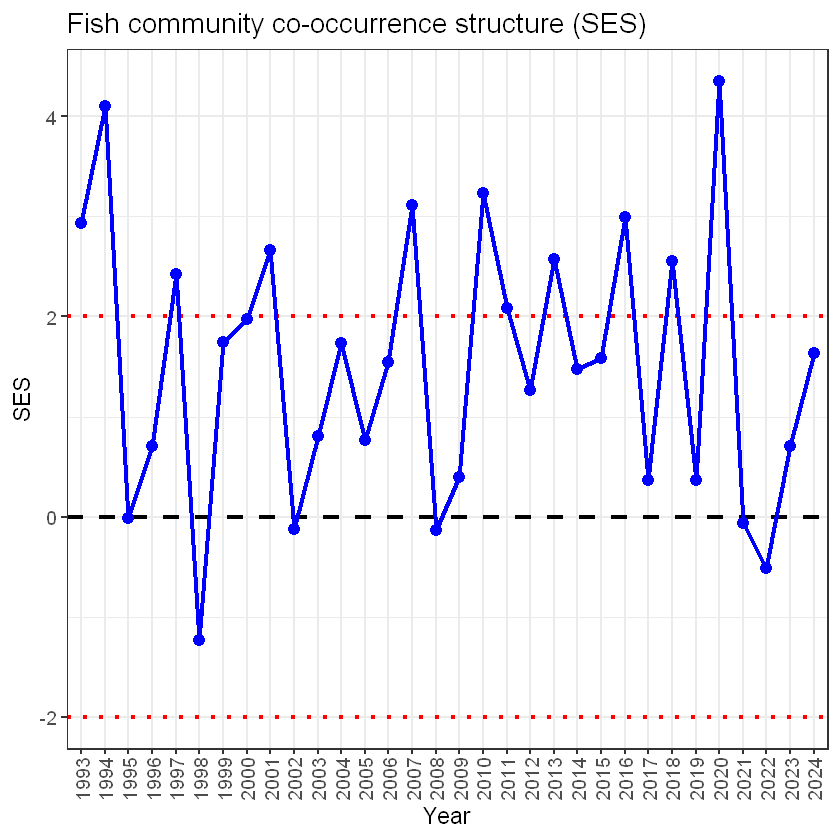

In [34]:
year_chunks <- list(1993:1999, 2000:2007, 2008:2014, 2015:2024)
run_ecosim_loop(pool=26, year_chunks) 

year_chunks <- c(1993:2024)
run_ecosim_loop(pool=26, year_chunks)


# La Grange

## <= 2007

[1]  57 540
     D1.RS_1993_LG D10.RS_1993_LG D11.RS_1993_LG D12.RS_1993_LG D13.RS_1993_LG
BHCP             0              0              0              0              0
BHMW             0              0              0              0              0
BKBF             0              0              0              0              0
BKCP             0              1              0              0              0
BKSS             0              0              0              0              0
Species: 57 
Sites: 540 
Total presences: 6839 
Fill percent: 0.22 
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
Time Stamp:  Thu May  7 21:14:42 2026 
Reproducible:  
Number of Replications:  
Elapsed Time:  22 secs 
Metric:  c_score 
Algorithm:  sim9 
Observed Index:  2632.2 
Mean Of Simulated Index:  2573.2 
Variance Of Simulated Index:  32.579 
Lower 95% (1-ta

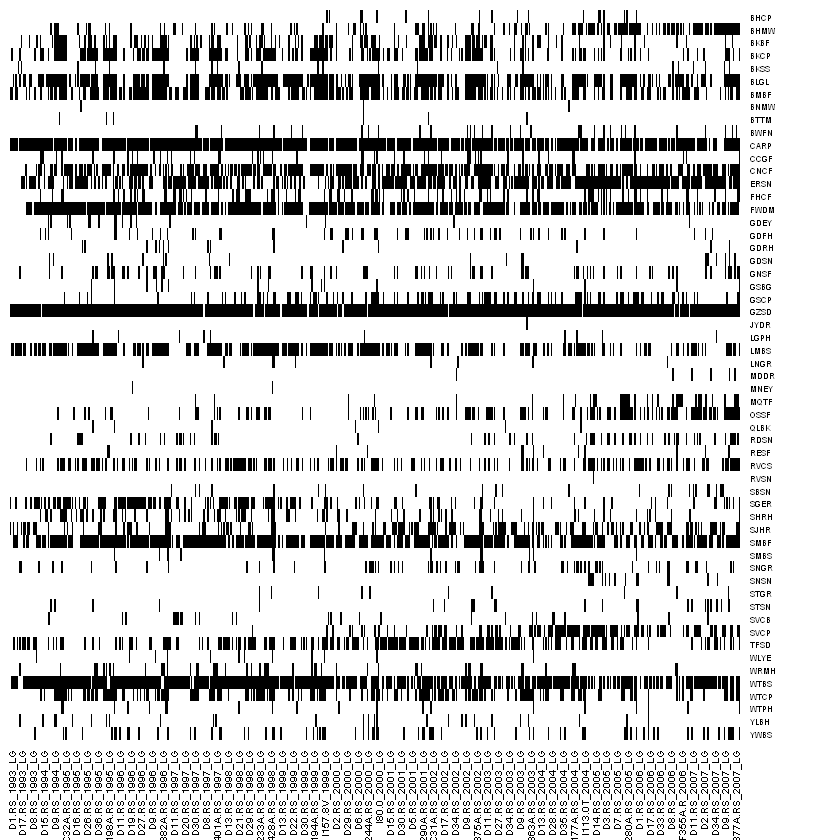

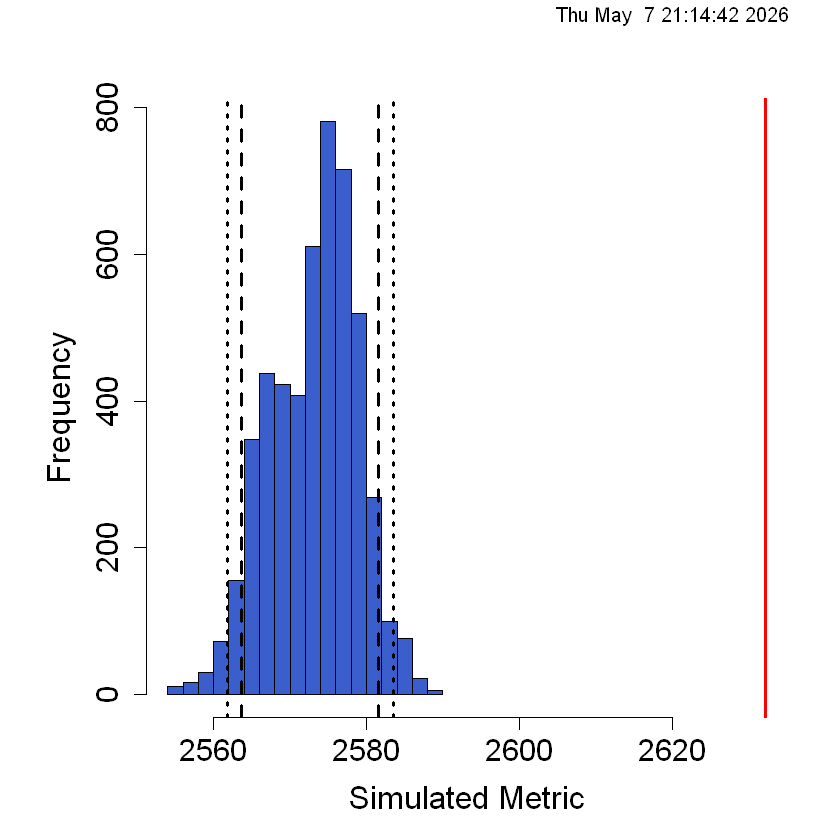

In [35]:
run_ecosim(pool="LG", breakpoint="<=2007")

## > 2007

[1]  61 679
     D1.RS_2008_LG D10.RS_2008_LG D11.RS_2008_LG D12.RS_2008_LG D13.RS_2008_LG
BHCP             0              0              0              0              0
BHMW             0              0              0              0              0
BKBF             0              0              0              0              0
BKCP             0              0              0              0              0
BKSS             0              0              0              0              0
Species: 61 
Sites: 679 
Total presences: 8324 
Fill percent: 0.2 
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
Time Stamp:  Thu May  7 21:15:12 2026 
Reproducible:  
Number of Replications:  
Elapsed Time:  29 secs 
Metric:  c_score 
Algorithm:  sim9 
Observed Index:  4831.7 
Mean Of Simulated Index:  4789.1 
Variance Of Simulated Index:  48.776 
Lower 95% (1-tai

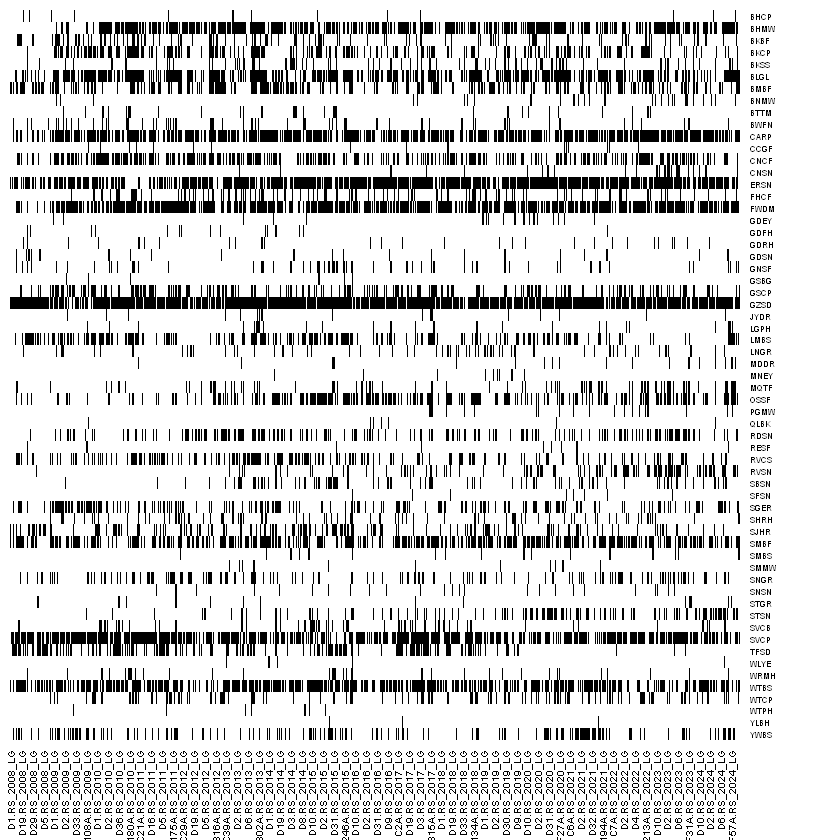

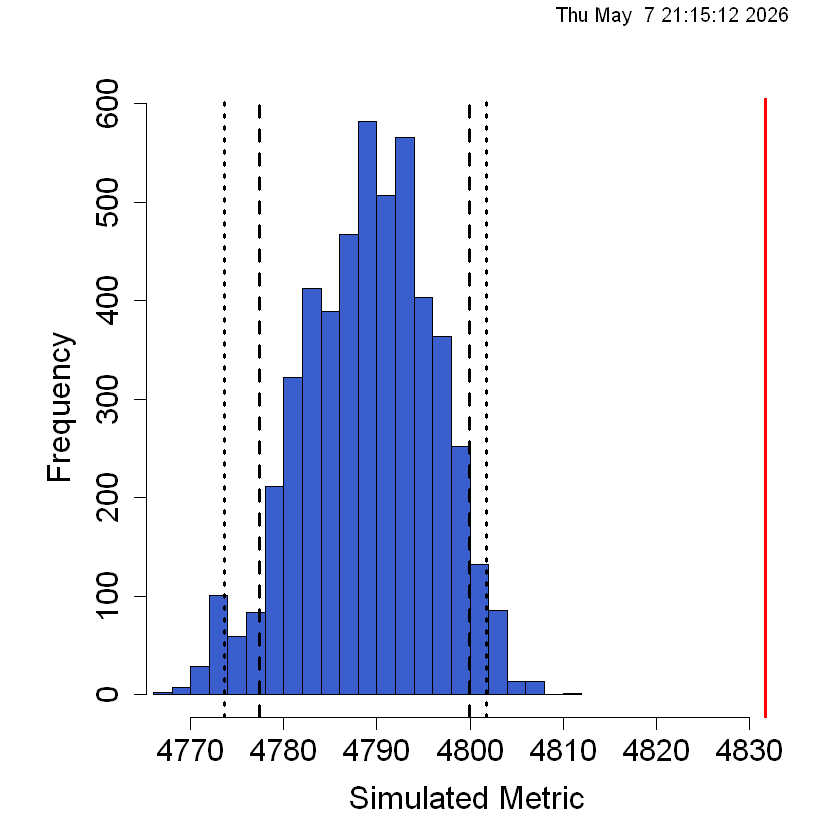

In [36]:
run_ecosim(pool="LG", breakpoint=">2007")

## SES year chunks

[1] "Running years: 1993-1999"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 2000-2007"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 2008-2014"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 2015-2024"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 1993-1993"
Burn-in Progress 
  |====================================================

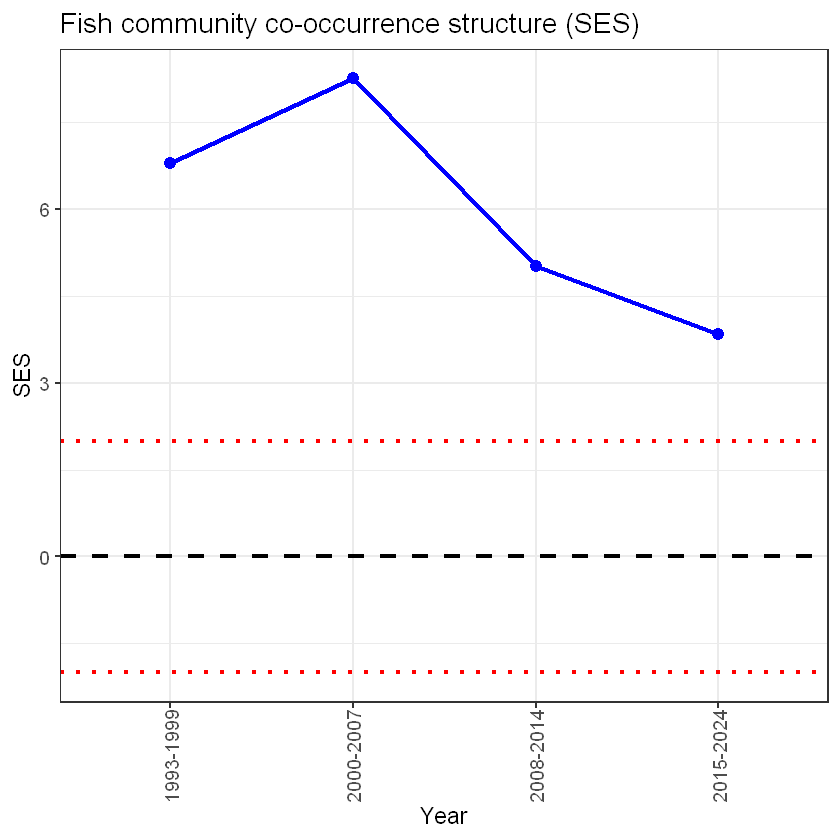

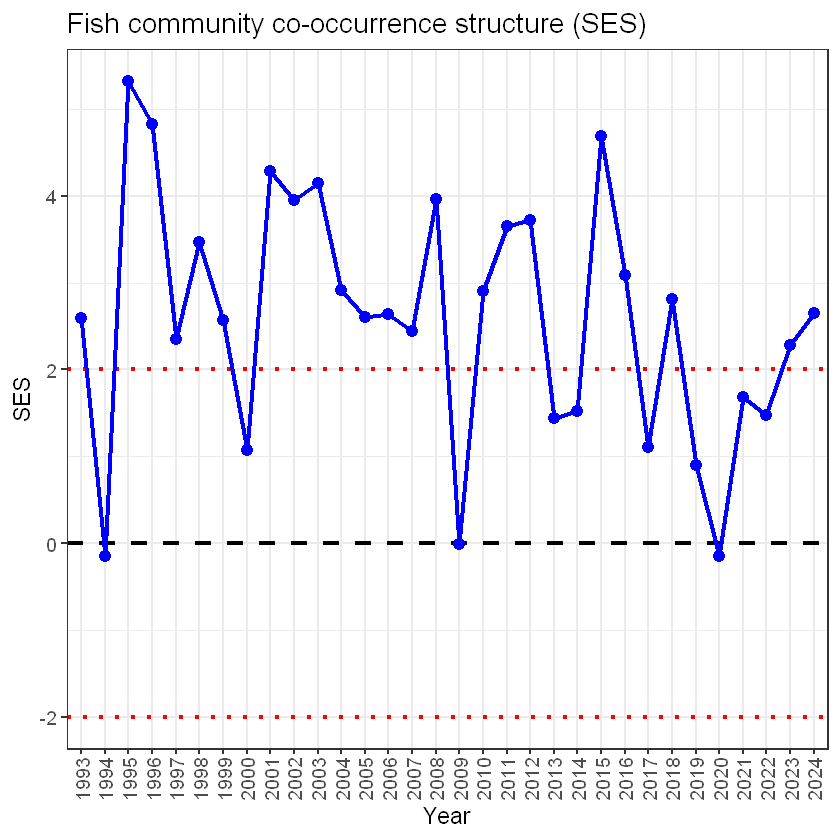

In [37]:
year_chunks <- list(1993:1999, 2000:2007, 2008:2014, 2015:2024)
run_ecosim_loop(pool="LG", year_chunks) 

year_chunks <- c(1993:2024)
run_ecosim_loop(pool="LG", year_chunks)
